In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install mne

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 82.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os
import numpy as np
import mne
import random
import time
import gc
from scipy.signal import butter, filtfilt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')


def force_remount():
    print("\nDetected Drive disconnection. Attempting to remount...")
    try:
        drive.flush_and_unmount()
    except:
        pass
    time.sleep(5)
    drive.mount('/content/drive', force_remount=True)
    print("Drive remounted successfully.\n")

drive.mount('/content/drive', force_remount=True)

BASE_DRIVE_PATH = '/content/drive/MyDrive/gp_dataset'
NORMAL_INPUT_PATH = os.path.join(BASE_DRIVE_PATH, 'abnormal_v3.0.1/edf/train/normal')
ABNORMAL_INPUT_PATH = os.path.join(BASE_DRIVE_PATH, 'abnormal_v3.0.1/edf/train/abnormal')

OUTPUT_BASE_DIR = '/content/drive/MyDrive/gp_dataset/preprocessing_paper_99/train'

TARGET_FILES_COUNT = 700
WINDOW_SIZE = 60   
STRIDE = 60        
SFREQ = 100        
MAX_MINUTES = 20   

REQUIRED_CHANNELS = [
    'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ'
]

def apply_bandpass(data, fs):
    nyq = 0.5 * fs
    b, a = butter(5, [0.5/nyq, 40.0/nyq], btype='band')
    return filtfilt(b, a, data, axis=1)

def apply_global_normalization(data, g_mean, g_std):
    g_mean = g_mean.reshape(-1, 1)
    g_std = g_std.reshape(-1, 1)
    normalized = (data - g_mean) / (g_std + 1e-8)
    return np.clip(normalized, -5, 5)

def get_selected_files(path, count):
    all_files = [os.path.join(root, file) for root, dirs, files in os.walk(path) for file in files if file.endswith('.edf')]
    if len(all_files) <= count:
        random.shuffle(all_files)
        return all_files
    return random.sample(all_files, count)

def compute_global_stats(files):
    print("\nCalculating Global Mean & Std...")
    total_sum = np.zeros(len(REQUIRED_CHANNELS))
    total_sq_sum = np.zeros(len(REQUIRED_CHANNELS))
    total_count = 0

    for edf_path in tqdm(files[:100], desc="Estimating Stats (100 files)"): 
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
            new_names = {ch: ch.upper().replace('EEG ', '').replace('-REF', '').replace('-LE', '') for ch in raw.ch_names}
            raw.rename_channels(new_names)

            if not all(ch in raw.ch_names for ch in REQUIRED_CHANNELS): continue

            raw.pick_channels(REQUIRED_CHANNELS, ordered=True)
            if raw.info['sfreq'] != SFREQ: raw.resample(SFREQ)

            filt_data = apply_bandpass(raw.get_data(), SFREQ)
            total_sum += np.sum(filt_data, axis=1)
            total_sq_sum += np.sum(filt_data ** 2, axis=1)
            total_count += filt_data.shape[1]
            raw.close()
        except OSError as e: 
            if "Transport endpoint" in str(e) or "Input/output" in str(e):
                force_remount()
        except: continue

    g_mean = total_sum / total_count
    g_std = np.sqrt((total_sq_sum / total_count) - (g_mean ** 2))
    return g_mean, g_std

def process_and_save_per_patient(files_list, class_name, g_mean, g_std):
    save_dir = os.path.join(OUTPUT_BASE_DIR, class_name)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\nProcessing {class_name.upper()} patients...")
    successful_patients = 0

    for idx, edf_path in enumerate(tqdm(files_list)):
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
            new_names = {ch: ch.upper().replace('EEG ', '').replace('-REF', '').replace('-LE', '') for ch in raw.ch_names}
            raw.rename_channels(new_names)

            if not all(ch in raw.ch_names for ch in REQUIRED_CHANNELS): continue
            raw.pick_channels(REQUIRED_CHANNELS, ordered=True)
            if raw.info['sfreq'] != SFREQ: raw.resample(SFREQ)

            data = raw.get_data()

            start_idx = 1 * 60 * SFREQ
            end_idx = start_idx + (MAX_MINUTES * 60 * SFREQ)
            data = data[:, start_idx:end_idx]

            filt_data = apply_bandpass(data, SFREQ)
            norm_data = apply_global_normalization(filt_data, g_mean, g_std)

            window_samples = WINDOW_SIZE * SFREQ
            n_windows = norm_data.shape[1] // window_samples
            if n_windows == 0: continue 

            patient_windows = []
            for i in range(n_windows):
                start = i * window_samples
                patient_windows.append(norm_data[:, start:start+window_samples])

            patient_array = np.array(patient_windows, dtype=np.float32) 

            np.save(os.path.join(save_dir, f'patient_{idx:04d}.npy'), patient_array)
            successful_patients += 1

            raw.close()
            del raw, data, filt_data, norm_data, patient_array
            gc.collect()

        except OSError as e: 
            if "Transport endpoint" in str(e) or "Input/output" in str(e):
                force_remount()
                time.sleep(2) 
        except Exception as e:
            continue

    print(f"Saved {successful_patients} {class_name} patients.")


if __name__ == "__main__":
    normal_files = get_selected_files(NORMAL_INPUT_PATH, TARGET_FILES_COUNT)
    abnormal_files = get_selected_files(ABNORMAL_INPUT_PATH, TARGET_FILES_COUNT)

    g_mean, g_std = compute_global_stats(normal_files + abnormal_files)

    os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
    np.save(os.path.join(OUTPUT_BASE_DIR, 'global_mean.npy'), g_mean)
    np.save(os.path.join(OUTPUT_BASE_DIR, 'global_std.npy'), g_std)

    process_and_save_per_patient(normal_files, 'normal', g_mean, g_std)
    process_and_save_per_patient(abnormal_files, 'abnormal', g_mean, g_std)
    print("\nPREPROCESSING COMPLETE! Data is ready for Window Stacking.")

Mounted at /content/drive

Calculating Global Mean & Std...
Estimating Stats (100 files):  13% 13/100 [00:34<03:08,  2.17s/it]

Detected Drive disconnection. Attempting to remount...

Estimating Stats (100 files):  14% 14/100 [03:50<1:26:57, 60.67s/it]
Mounted at /content/drive
Drive remounted successfully.

Estimating Stats (100 files): 100% 100/100 [06:15<00:00,  3.76s/it]

Processing NORMAL patients...
100% 700/700 [22:34<00:00,  1.94s/it]
Saved 700 normal patients.

Processing ABNORMAL patients...
100% 700/700 [26:32<00:00,  2.27s/it]
Saved 700 abnormal patients.

PREPROCESSING COMPLETE! Data is ready for Window Stacking.



Found Raw Normal: aaaaakvr_s001_t000.edf
Found Raw Abnormal: aaaaaicb_s001_t000.edf
Found Proc Normal: patient_0000.npy
Found Proc Abnormal: patient_0000.npy
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).



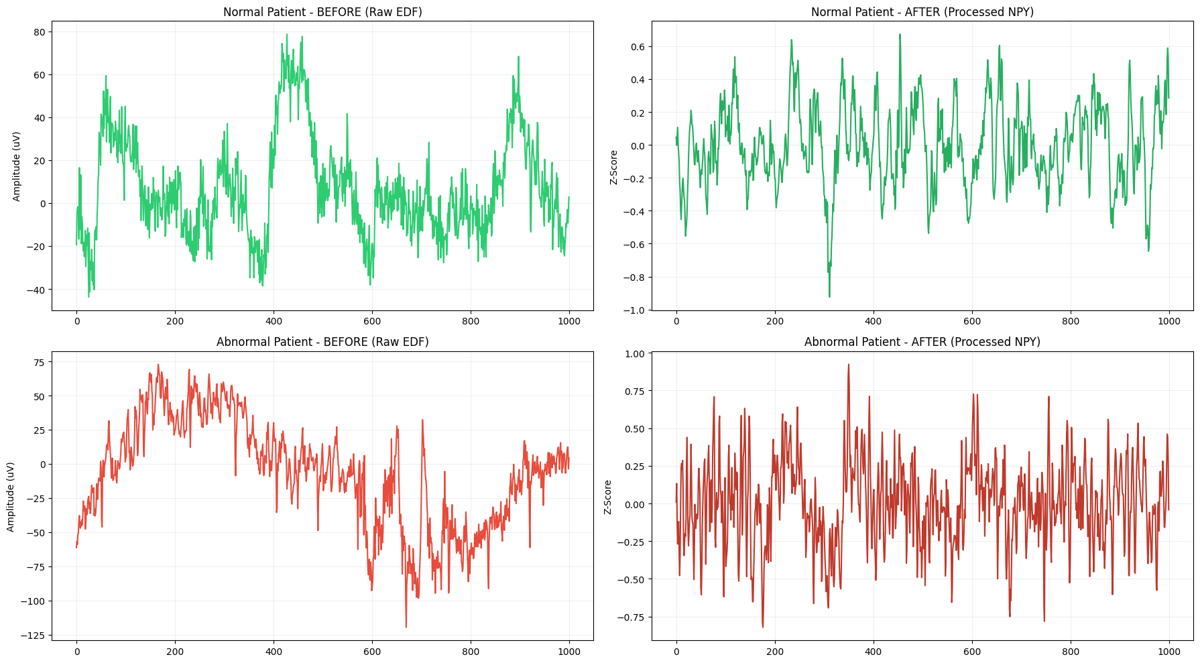

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

RAW_BASE_NORMAL = '/content/drive/MyDrive/gp_dataset/abnormal_v3.0.1/edf/train/normal'
RAW_BASE_ABNORMAL = '/content/drive/MyDrive/gp_dataset/abnormal_v3.0.1/edf/train/abnormal'

PROC_BASE_NORMAL = '/content/drive/MyDrive/gp_dataset/preprocessing_v2/train/normal'
PROC_BASE_ABNORMAL = '/content/drive/MyDrive/gp_dataset/preprocessing_v2/train/abnormal'

REQUIRED_CHANNELS = ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
                     'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
SFREQ = 100

def find_first_file_recursive(base_path, extension):
    if not os.path.exists(base_path):
        return None
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(extension):
                return os.path.join(root, file)
    return None

def plot_comprehensive_comparison():
    raw_n_path = find_first_file_recursive(RAW_BASE_NORMAL, '.edf')
    raw_a_path = find_first_file_recursive(RAW_BASE_ABNORMAL, '.edf')
    proc_n_path = find_first_file_recursive(PROC_BASE_NORMAL, '.npy')
    proc_a_path = find_first_file_recursive(PROC_BASE_ABNORMAL, '.npy')

    files_check = {
        "Raw Normal": raw_n_path,
        "Raw Abnormal": raw_a_path,
        "Proc Normal": proc_n_path,
        "Proc Abnormal": proc_a_path
    }

    found_all = True
    for name, path in files_check.items():
        if path:
            print(f"Found {name}: {os.path.basename(path)}")
        else:
            print(f"Missing {name}! Check path: {name}")
            found_all = False

    if not found_all: return

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    ch_idx = 0 

    raw_n = mne.io.read_raw_edf(raw_n_path, preload=True, verbose=False)
    mapping = {ch: ch.upper().replace('EEG ', '').replace('-REF', '').replace('-LE', '') for ch in raw_n.ch_names}
    raw_n.rename_channels(mapping)
    raw_n.pick_channels([REQUIRED_CHANNELS[ch_idx]])
    raw_n.resample(SFREQ)
    d_raw_n = raw_n.get_data()[0, 60*SFREQ : 70*SFREQ] * 1e6
    axes[0, 0].plot(d_raw_n, color='#2ecc71')
    axes[0, 0].set_title("Normal Patient - BEFORE (Raw EDF)")
    axes[0, 0].set_ylabel("Amplitude (uV)")

    raw_a = mne.io.read_raw_edf(raw_a_path, preload=True, verbose=False)
    raw_a.rename_channels(mapping)
    raw_a.pick_channels([REQUIRED_CHANNELS[ch_idx]])
    raw_a.resample(SFREQ)
    d_raw_a = raw_a.get_data()[0, 60*SFREQ : 70*SFREQ] * 1e6
    axes[1, 0].plot(d_raw_a, color='#e74c3c')
    axes[1, 0].set_title("Abnormal Patient - BEFORE (Raw EDF)")
    axes[1, 0].set_ylabel("Amplitude (uV)")

    proc_n = np.load(proc_n_path)
    axes[0, 1].plot(proc_n[0, ch_idx, :1000], color='#27ae60')
    axes[0, 1].set_title("Normal Patient - AFTER (Processed NPY)")
    axes[0, 1].set_ylabel("Z-Score")

    proc_a = np.load(proc_a_path)
    axes[1, 1].plot(proc_a[0, ch_idx, :1000], color='#c0392b')
    axes[1, 1].set_title("Abnormal Patient - AFTER (Processed NPY)")
    axes[1, 1].set_ylabel("Z-Score")

    for ax in axes.flat:
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_comprehensive_comparison()

In [ ]:
from google.colab import drive
import os
import numpy as np
import mne
import random
import time
import gc
from scipy.signal import butter, filtfilt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

def force_remount():
    print("\nDetected Drive disconnection. Attempting to remount...")
    try:
        drive.flush_and_unmount()
    except:
        pass
    time.sleep(5)
    drive.mount('/content/drive', force_remount=True)
    print("Drive remounted successfully.\n")

drive.mount('/content/drive', force_remount=True)

BASE_DRIVE_PATH = '/content/drive/MyDrive/gp_dataset'

EVAL_NORMAL = os.path.join(BASE_DRIVE_PATH, 'abnormal_v3.0.1/edf/eval/normal')
EVAL_ABNORMAL = os.path.join(BASE_DRIVE_PATH, 'abnormal_v3.0.1/edf/eval/abnormal')

TRAIN_DIR_WITH_STATS = '/content/drive/MyDrive/gp_dataset/preprocessing_v2/train'
OUTPUT_EVAL_DIR = '/content/drive/MyDrive/gp_dataset/preprocessing_v2/eval'

TARGET_EVAL_FILES = 500

WINDOW_SIZE = 60
STRIDE = 60
SFREQ = 100
MAX_MINUTES = 20

REQUIRED_CHANNELS = [
    'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ'
]


def apply_bandpass(data, fs):
    nyq = 0.5 * fs
    b, a = butter(5, [0.5/nyq, 40.0/nyq], btype='band')
    return filtfilt(b, a, data, axis=1)

def apply_global_normalization(data, g_mean, g_std):
    g_mean = g_mean.reshape(-1, 1)
    g_std = g_std.reshape(-1, 1)
    normalized = (data - g_mean) / (g_std + 1e-8)
    return np.clip(normalized, -5, 5)

def get_selected_files(path, count):
    all_files = [os.path.join(root, file) for root, dirs, files in os.walk(path) for file in files if file.endswith('.edf')]
    if len(all_files) <= count:
        random.shuffle(all_files)
        return all_files
    return random.sample(all_files, count)

def process_and_save_per_patient(files_list, class_name, save_base_dir, g_mean, g_std):
    save_dir = os.path.join(save_base_dir, class_name)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\nProcessing {class_name.upper()} patients for EVAL...")
    successful_patients = 0

    for idx, edf_path in enumerate(tqdm(files_list)):
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
            new_names = {ch: ch.upper().replace('EEG ', '').replace('-REF', '').replace('-LE', '') for ch in raw.ch_names}
            raw.rename_channels(new_names)

            if not all(ch in raw.ch_names for ch in REQUIRED_CHANNELS): continue
            raw.pick_channels(REQUIRED_CHANNELS, ordered=True)
            if raw.info['sfreq'] != SFREQ: raw.resample(SFREQ)

            data = raw.get_data()

            start_idx = 1 * 60 * SFREQ
            end_idx = start_idx + (MAX_MINUTES * 60 * SFREQ)
            data = data[:, start_idx:end_idx]

            filt_data = apply_bandpass(data, SFREQ)
            norm_data = apply_global_normalization(filt_data, g_mean, g_std)

            window_samples = WINDOW_SIZE * SFREQ
            n_windows = norm_data.shape[1] // window_samples
            if n_windows == 0: continue

            patient_windows = []
            for i in range(n_windows):
                start = i * window_samples
                patient_windows.append(norm_data[:, start:start+window_samples])

            patient_array = np.array(patient_windows, dtype=np.float32)

            np.save(os.path.join(save_dir, f'ev_patient_{idx:04d}.npy'), patient_array)
            successful_patients += 1

            raw.close()
            del raw, data, filt_data, norm_data, patient_array
            gc.collect()

        except OSError as e:
            if "Transport endpoint" in str(e) or "Input/output" in str(e):
                force_remount()
                time.sleep(2)
        except Exception as e:
            continue

    print(f"Saved {successful_patients} {class_name} patients in EVAL.")


if __name__ == "__main__":
    print("\nStep 1: Selecting EVAL files...")
    eval_normal = get_selected_files(EVAL_NORMAL, TARGET_EVAL_FILES)
    eval_abnormal = get_selected_files(EVAL_ABNORMAL, TARGET_EVAL_FILES)

    print("\nStep 2: Loading pre-computed global stats from TRAIN...")
    mean_path = os.path.join(TRAIN_DIR_WITH_STATS, 'global_mean.npy')
    std_path = os.path.join(TRAIN_DIR_WITH_STATS, 'global_std.npy')

    if not os.path.exists(mean_path) or not os.path.exists(std_path):
        raise ValueError(f"Could not find global stats in {TRAIN_DIR_WITH_STATS}. Ensure paths are correct.")

    g_mean = np.load(mean_path)
    g_std = np.load(std_path)
    print("Train stats loaded successfully.")

    print("\nStep 3: Processing EVAL Data...")
    process_and_save_per_patient(eval_normal, 'normal', OUTPUT_EVAL_DIR, g_mean, g_std)
    process_and_save_per_patient(eval_abnormal, 'abnormal', OUTPUT_EVAL_DIR, g_mean, g_std)

    print("\nEVAL PREPROCESSING COMPLETE! You are ready to evaluate the model.")

Mounted at /content/drive

Step 1: Selecting EVAL files...

Step 2: Loading pre-computed global stats from TRAIN...
Train stats loaded successfully.

Step 3: Processing EVAL Data...

Processing NORMAL patients for EVAL...
100% 150/150 [05:02<00:00,  2.02s/it]
Saved 150 normal patients in EVAL.

Processing ABNORMAL patients for EVAL...
100% 126/126 [06:56<00:00,  3.30s/it]
Saved 126 abnormal patients in EVAL.

EVAL PREPROCESSING COMPLETE! You are ready to evaluate the model.

